# CNN for Handwritten Digits 51–55

Trains a small CNN on a folder dataset (`dataset/51`, `dataset/52`, `dataset/53`, `dataset/54`, `dataset/55`) of 28×28 images and saves the weights as `model.safetensors`.

**Heads up about HTML use later:** browsers can't load `.safetensors` directly. When you're ready to wire it into your canvas page, the easiest path is to also export ONNX (one extra cell at the bottom does this) and run it in the browser with `onnxruntime-web`.

In [ ]:
!pip -q install safetensors onnxscript onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 11.4 MB/s eta 0:00:00


## 1. Upload / locate the dataset

Pick **one** of the options below.

**Option A — upload a zipped `dataset.zip` from your computer:**

In [ ]:
from google.colab import files
import zipfile, os

uploaded = files.upload()  # choose dataset.zip
zip_name = next(iter(uploaded))
with zipfile.ZipFile(zip_name) as z:
    z.extractall('.')

DATA_DIR = 'dataset'
print('classes found:', sorted(os.listdir(DATA_DIR)))

Saving dataset.zip to dataset.zip
classes found: ['51', '52', '53', '54', '55']


**Option B — mount Google Drive instead** (skip Option A if you use this):

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/dataset'  # adjust path

## 2. Imports + config

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cpu':
    print('WARNING: no GPU detected. In Colab: Runtime -> Change runtime type -> T4 GPU.')

BATCH_SIZE = 64
EPOCHS     = 80          # harder augmented data needs more time to converge
LR         = 1e-3
VAL_SPLIT  = 0.15
SEED       = 42
torch.manual_seed(SEED)

device: cuda


## 3. Dataset

`ImageFolder` reads each subfolder as one class. Class indices are alphabetical, so `51→51` etc. — we keep `idx_to_label = ['51','52','53','54','55']` for use at inference.

In [ ]:
train_tfm = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.12, 0.12),
        scale=(0.75, 1.25),
        shear=8,
        fill=255,
    ),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.4, fill=255),
    transforms.RandomApply([transforms.ElasticTransform(alpha=20.0, sigma=4.0)], p=0.25),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.2))], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
eval_tfm = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.ImageFolder(DATA_DIR, transform=train_tfm)
full_eval  = datasets.ImageFolder(DATA_DIR, transform=eval_tfm)
assert full_train.classes == ['51','52','53','54','55'], full_train.classes
idx_to_label = full_train.classes
print('classes (idx -> label):', dict(enumerate(idx_to_label)))

from collections import Counter
counts = Counter([y for _, y in full_train.samples])
print('per-class counts:', {idx_to_label[i]: counts[i] for i in range(len(idx_to_label))})

n_total = len(full_train)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val
g = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(range(n_total), [n_train, n_val], generator=g)
train_ds = torch.utils.data.Subset(full_train, list(train_idx))
val_ds   = torch.utils.data.Subset(full_eval,  list(val_idx))

pin = (device.type == 'cuda')
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=pin)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin)
print(f'train: {len(train_ds)}   val: {len(val_ds)}')

classes (idx -> label): {0: '51', 1: '52', 2: '53', 3: '54', 4: '55'}
per-class counts: {'51': 100, '52': 100, '53': 100, '54': 100, '55': 100}
train: 425   val: 75


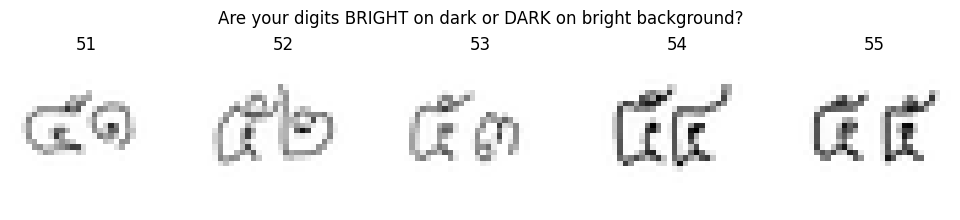

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Show one image per class so you can confirm polarity (black-on-white vs white-on-black).
fig, axes = plt.subplots(1, len(idx_to_label), figsize=(2*len(idx_to_label), 2.2))
for ax, cls in zip(axes, idx_to_label):
    sample_path = next(p for p, y in full_train.samples if idx_to_label[y] == cls)
    img = Image.open(sample_path).convert('L').resize((28, 28))
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(cls); ax.axis('off')
plt.suptitle('Are your digits BRIGHT on dark or DARK on bright background?')
plt.tight_layout(); plt.show()


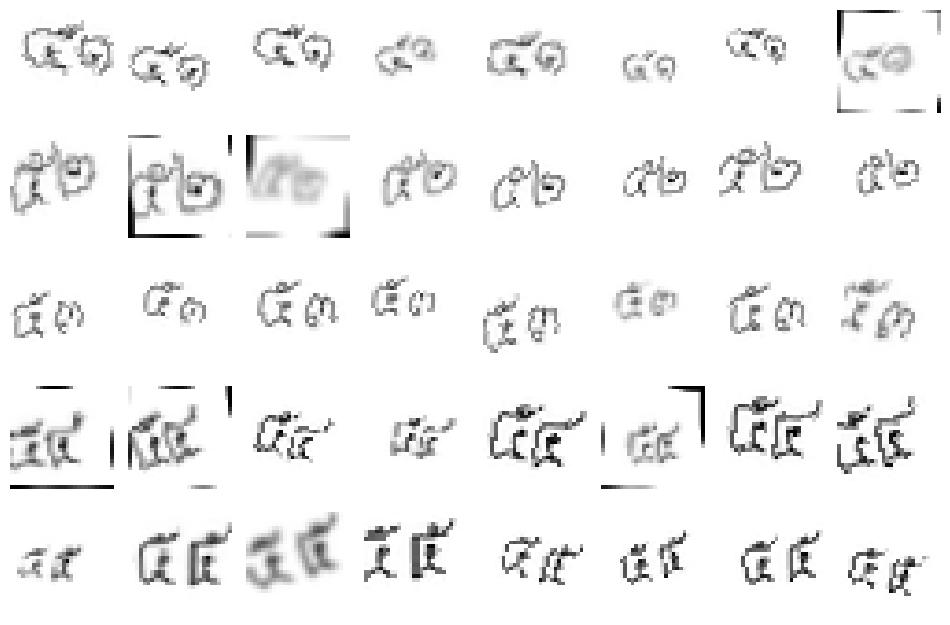

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

N_VARIANTS = 8
fig, axes = plt.subplots(len(idx_to_label), N_VARIANTS, figsize=(N_VARIANTS * 1.2, len(idx_to_label) * 1.3))
for row, cls in enumerate(idx_to_label):
    sample_path = next(p for p, y in full_train.samples if idx_to_label[y] == cls)
    pil = Image.open(sample_path)
    for col in range(N_VARIANTS):
        t = train_tfm(pil)
        img = (t.squeeze(0) * 0.3081 + 0.1307).clamp(0, 1).numpy()
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(cls, rotation=0, labelpad=18, fontsize=12)
plt.tight_layout(); plt.show()

## 4. Model

In [ ]:
class DigitCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.20)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.drop2 = nn.Dropout(0.30)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 28 -> 14
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 14 -> 7
        x = self.drop1(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop2(x)
        return self.fc2(x)

model = DigitCNN(num_classes=len(idx_to_label)).to(device)
print(model)

DigitCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


## 5. Train

In [ ]:
opt    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
lossfn = nn.CrossEntropyLoss()    # no label smoothing — let the model be confident

def run_epoch(loader, train):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            logits = model(x)
            loss   = lossfn(logits, y)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
        loss_sum += loss.item() * x.size(0)
        correct  += (logits.argmax(1) == y).sum().item()
        total    += x.size(0)
    return loss_sum / total, correct / total

best_acc = 0.0
history  = []
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_dl, train=True)
    va_loss, va_acc = run_epoch(val_dl,   train=False)
    sched.step()
    history.append((epoch, tr_loss, tr_acc, va_loss, va_acc))
    flag = ''
    if va_acc > best_acc:
        best_acc = va_acc
        torch.save(model.state_dict(), 'best.pt')
        flag = '  <-- best'
    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS or flag:
        print(f'epoch {epoch:02d}  train {tr_loss:.4f}/{tr_acc:.3f}   val {va_loss:.4f}/{va_acc:.3f}{flag}')

print(f'best val acc: {best_acc:.3f}')


epoch 01  train 1.7485/0.259   val 1.5634/0.320  <-- best
epoch 02  train 1.5304/0.304   val 1.4313/0.533  <-- best
epoch 04  train 1.3229/0.424   val 1.1054/0.667  <-- best
epoch 05  train 1.3004/0.428   val 0.9768/0.613
epoch 10  train 1.0876/0.520   val 0.8195/0.680  <-- best
epoch 11  train 1.0042/0.588   val 0.7776/0.707  <-- best
epoch 12  train 0.9826/0.600   val 0.6756/0.760  <-- best
epoch 13  train 1.0160/0.565   val 0.6050/0.800  <-- best
epoch 15  train 0.8465/0.645   val 0.5054/0.840  <-- best
epoch 17  train 0.8329/0.654   val 0.4257/0.867  <-- best
epoch 18  train 0.7888/0.696   val 0.4375/0.893  <-- best
epoch 20  train 0.7792/0.682   val 0.3599/0.867
epoch 23  train 0.6708/0.727   val 0.2488/0.973  <-- best
epoch 25  train 0.5967/0.762   val 0.1825/0.973
epoch 27  train 0.5604/0.774   val 0.1505/0.987  <-- best
epoch 29  train 0.5594/0.791   val 0.1363/1.000  <-- best
epoch 30  train 0.5266/0.795   val 0.1477/0.947
epoch 35  train 0.4320/0.833   val 0.0924/1.000
epoch 

## 5b. Evaluation: accuracy, precision, recall, F1, confusion matrix

Loads the best checkpoint, runs it over the validation set, and renders four charts:

- **Confusion matrix** heatmap (where the mistakes are)
- **Per-class precision / recall / F1** bars
- **Loss curves** across all epochs (train vs val)
- **Accuracy curves** across all epochs (train vs val)

The cell after this one grids any misclassified validation images so you can eyeball *what* the model got wrong.

Accuracy : 1.0000
Precision: 1.0000  (macro)
Recall   : 1.0000  (macro)
F1-score : 1.0000  (macro)

              precision    recall  f1-score   support

          51     1.0000    1.0000    1.0000        11
          52     1.0000    1.0000    1.0000        14
          53     1.0000    1.0000    1.0000        19
          54     1.0000    1.0000    1.0000        18
          55     1.0000    1.0000    1.0000        13

    accuracy                         1.0000        75
   macro avg     1.0000    1.0000    1.0000        75
weighted avg     1.0000    1.0000    1.0000        75



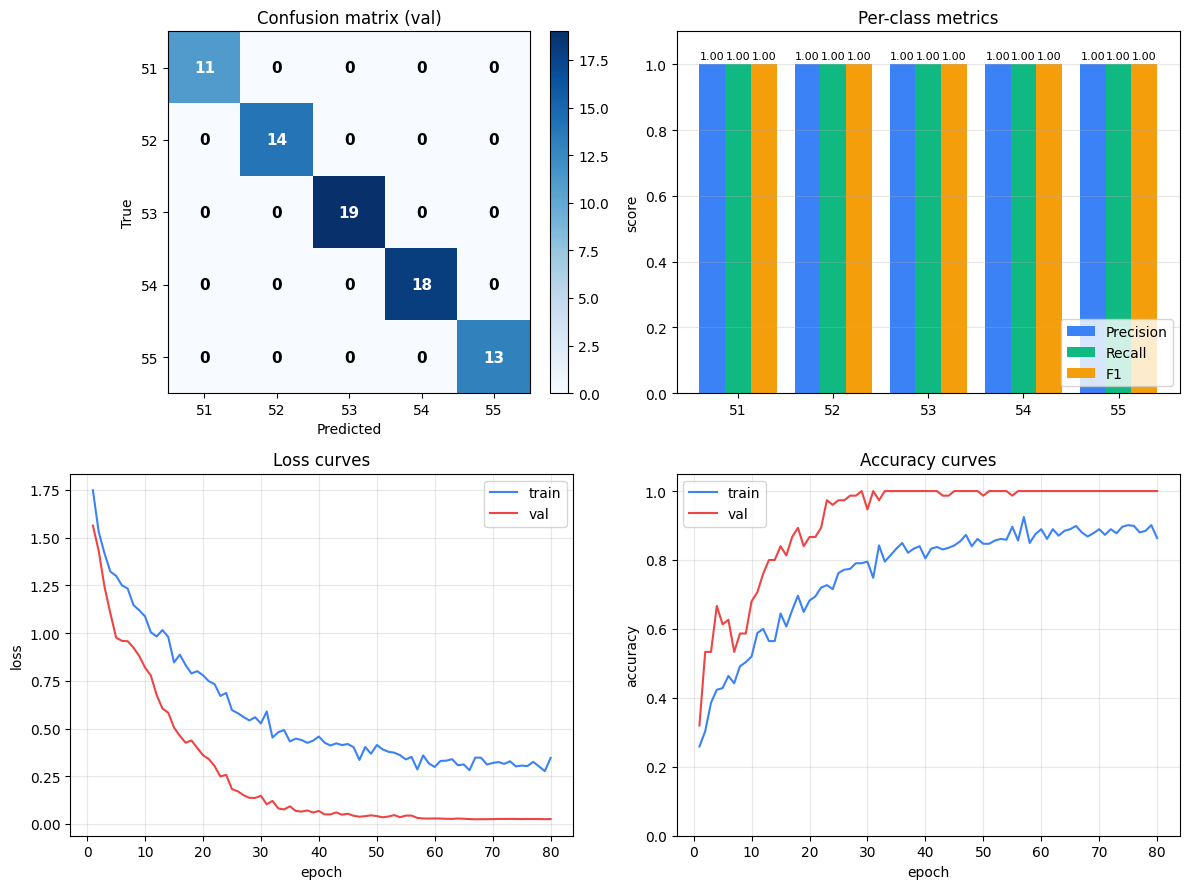

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    precision_recall_fscore_support,
)

model.load_state_dict(torch.load('best.pt', map_location=device))
model.eval()

all_y, all_p, all_imgs = [], [], []
with torch.no_grad():
    for x, y in val_dl:
        xd = x.to(device)
        pred = model(xd).argmax(1).cpu().numpy()
        all_y.extend(y.numpy()); all_p.extend(pred); all_imgs.extend(x.numpy())
all_y    = np.array(all_y)
all_p    = np.array(all_p)
all_imgs = np.array(all_imgs)

acc        = accuracy_score(all_y, all_p)
prec_macro = precision_score(all_y, all_p, average='macro', zero_division=0)
rec_macro  = recall_score(all_y, all_p,    average='macro', zero_division=0)
f1_macro   = f1_score(all_y, all_p,        average='macro', zero_division=0)
prec, rec, f1, support = precision_recall_fscore_support(all_y, all_p, zero_division=0)
cm = confusion_matrix(all_y, all_p)

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec_macro:.4f}  (macro)')
print(f'Recall   : {rec_macro:.4f}  (macro)')
print(f'F1-score : {f1_macro:.4f}  (macro)\n')
print(classification_report(all_y, all_p, target_names=idx_to_label, zero_division=0, digits=4))

# ---------------- 4-panel evaluation figure ----------------
fig, ((ax_cm, ax_bar), (ax_loss, ax_acc)) = plt.subplots(2, 2, figsize=(12, 9))

# (a) confusion matrix heatmap
im = ax_cm.imshow(cm, cmap='Blues')
ax_cm.set_xticks(range(len(idx_to_label))); ax_cm.set_xticklabels(idx_to_label)
ax_cm.set_yticks(range(len(idx_to_label))); ax_cm.set_yticklabels(idx_to_label)
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
ax_cm.set_title('Confusion matrix (val)')
thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax_cm.text(j, i, str(cm[i, j]),
                   ha='center', va='center',
                   color='white' if cm[i, j] > thresh else 'black',
                   fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

# (b) per-class precision / recall / F1
xpos = np.arange(len(idx_to_label))
w    = 0.27
ax_bar.bar(xpos - w, prec, w, label='Precision', color='#3b82f6')
ax_bar.bar(xpos,     rec,  w, label='Recall',    color='#10b981')
ax_bar.bar(xpos + w, f1,   w, label='F1',        color='#f59e0b')
ax_bar.set_xticks(xpos); ax_bar.set_xticklabels(idx_to_label)
ax_bar.set_ylim(0, 1.10); ax_bar.set_ylabel('score'); ax_bar.set_title('Per-class metrics')
ax_bar.grid(axis='y', alpha=0.3)
ax_bar.legend(loc='lower right')
for i, (p_v, r_v, f_v) in enumerate(zip(prec, rec, f1)):
    ax_bar.text(i - w, p_v + 0.015, f'{p_v:.2f}', ha='center', fontsize=8)
    ax_bar.text(i,     r_v + 0.015, f'{r_v:.2f}', ha='center', fontsize=8)
    ax_bar.text(i + w, f_v + 0.015, f'{f_v:.2f}', ha='center', fontsize=8)

# (c) and (d) training curves — uses `history` collected during training
if 'history' in globals() and history:
    epochs    = [h[0] for h in history]
    tr_losses = [h[1] for h in history]
    tr_accs   = [h[2] for h in history]
    va_losses = [h[3] for h in history]
    va_accs   = [h[4] for h in history]

    ax_loss.plot(epochs, tr_losses, label='train', color='#3b82f6')
    ax_loss.plot(epochs, va_losses, label='val',   color='#ef4444')
    ax_loss.set_xlabel('epoch'); ax_loss.set_ylabel('loss'); ax_loss.set_title('Loss curves')
    ax_loss.grid(alpha=0.3); ax_loss.legend()

    ax_acc.plot(epochs, tr_accs, label='train', color='#3b82f6')
    ax_acc.plot(epochs, va_accs, label='val',   color='#ef4444')
    ax_acc.set_xlabel('epoch'); ax_acc.set_ylabel('accuracy'); ax_acc.set_title('Accuracy curves')
    ax_acc.set_ylim(0, 1.05); ax_acc.grid(alpha=0.3); ax_acc.legend()
else:
    for ax in (ax_loss, ax_acc):
        ax.text(0.5, 0.5, '(no training history — re-run cell 5)',
                ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
mis_idx = np.where(all_y != all_p)[0]
if len(mis_idx) == 0:
    print('No misclassified validation samples — model got 100% on val.')
else:
    n_show = min(len(mis_idx), 15)
    cols   = 5
    rows   = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.9))
    axes = np.atleast_2d(axes).reshape(rows, cols)
    for k in range(rows * cols):
        ax = axes[k // cols, k % cols]
        if k < n_show:
            idx = mis_idx[k]
            img = all_imgs[idx, 0] * 0.3081 + 0.1307     # un-normalize
            img = np.clip(img, 0, 1)
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            ax.set_title(
                f'true {idx_to_label[all_y[idx]]} → pred {idx_to_label[all_p[idx]]}',
                fontsize=9,
            )
        ax.axis('off')
    plt.suptitle(f'{len(mis_idx)} misclassified val image(s)')
    plt.tight_layout()
    plt.show()

No misclassified validation samples — model got 100% on val.


### Per-class TP / FP / TN / FN matrices

The 5×5 confusion matrix above shows where each class confuses with each *other* class. For binary diagnostic terminology (TP, FP, TN, FN), each class becomes its own **one-vs-rest** problem: "is this prediction class `c` or not?" — giving a real 2×2 confusion matrix per class.

- **TP**: predicted `c`, actually `c`
- **FP**: predicted `c`, actually a different class
- **FN**: predicted not `c`, actually `c`
- **TN**: predicted not `c`, actually not `c`

From these we also derive **specificity** = `TN / (TN + FP)`, which `classification_report` doesn't print.

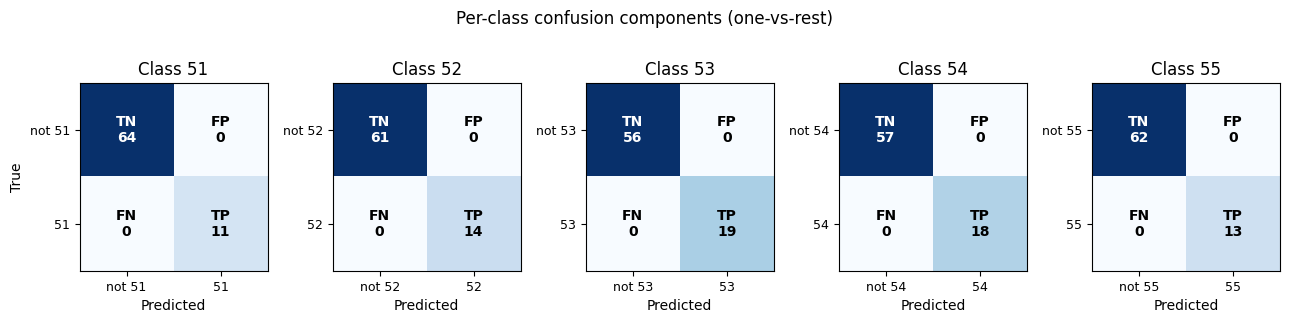


Class    TP   FP   FN   TN   Sensitivity  Specificity
------------------------------------------------------------
51       11    0    0   64        1.0000       1.0000
52       14    0    0   61        1.0000       1.0000
53       19    0    0   56        1.0000       1.0000
54       18    0    0   57        1.0000       1.0000
55       13    0    0   62        1.0000       1.0000


In [ ]:
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(all_y, all_p)   # shape (n_classes, 2, 2)

fig, axes = plt.subplots(1, len(idx_to_label), figsize=(2.6 * len(idx_to_label), 3.2))
axes = np.atleast_1d(axes)
for i, (ax, cls) in enumerate(zip(axes, idx_to_label)):
    m = mcm[i]                                     # [[TN, FP], [FN, TP]]
    ax.imshow(m, cmap='Blues', vmin=0)
    ax.set_xticks([0, 1]); ax.set_xticklabels([f'not {cls}', cls], fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels([f'not {cls}', cls], fontsize=9)
    ax.set_xlabel('Predicted')
    if i == 0:
        ax.set_ylabel('True')
    ax.set_title(f'Class {cls}')
    cell_labels = [['TN', 'FP'], ['FN', 'TP']]
    thresh = m.max() / 2.0 if m.max() > 0 else 0.5
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f'{cell_labels[r][c]}\n{m[r, c]}',
                    ha='center', va='center',
                    color='white' if m[r, c] > thresh else 'black',
                    fontsize=10, fontweight='bold')
plt.suptitle('Per-class confusion components (one-vs-rest)')
plt.tight_layout()
plt.show()

# Text summary table
print(f'\n{"Class":<6}{"TP":>5}{"FP":>5}{"FN":>5}{"TN":>5}   {"Sensitivity":>11}  {"Specificity":>11}')
print('-' * 60)
for i, cls in enumerate(idx_to_label):
    tn, fp, fn, tp = mcm[i].ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    print(f'{cls:<6}{tp:>5d}{fp:>5d}{fn:>5d}{tn:>5d}   {sens:>11.4f}  {spec:>11.4f}')

## 6. Save as `.safetensors`

In [ ]:
from safetensors.torch import save_file
import json

model.load_state_dict(torch.load('best.pt', map_location=device))
model.eval()

state = {k: v.contiguous().cpu() for k, v in model.state_dict().items()}
metadata = {
    'classes': json.dumps(idx_to_label),
    'input':   '1x28x28 grayscale, normalize mean=0.1307 std=0.3081',
    'arch':    'DigitCNN: Conv(1,32)->Pool->Conv(32,64)->Pool->FC(3136,128)->FC(128,5)',
}
save_file(state, 'model.safetensors', metadata=metadata)

with open('classes.json', 'w') as f:
    json.dump(idx_to_label, f)

from google.colab import files as gfiles
gfiles.download('model.safetensors')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Quick sanity check

In [ ]:
from safetensors.torch import load_file

m2 = DigitCNN(num_classes=len(idx_to_label)).to(device)
m2.load_state_dict(load_file('model.safetensors'))
m2.eval()

x, y = next(iter(val_dl))
x = x.to(device)
with torch.no_grad():
    pred = m2(x).argmax(1).cpu()
print('true :', [idx_to_label[i] for i in y[:16].tolist()])
print('pred :', [idx_to_label[i] for i in pred[:16].tolist()])

true : ['53', '51', '55', '52', '55', '52', '55', '51', '53', '54', '54', '53', '55', '52', '52', '53']
pred : ['53', '51', '55', '52', '55', '52', '55', '51', '53', '54', '54', '53', '55', '52', '52', '53']
